# Analisis de los datos

In [17]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Caracteristicas de las variables

In [4]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Final/final_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


In [33]:
df_final = dataFrame.copy()
df_final = df_final.drop(columns=['frp_sum', 'frp_mean', 'area_ha', 'count', 'date_last', 'duration_days'])

In [35]:
print(f"Columnas: {df_final.columns}")
print(f"La longitud total de los datos es de: {len(df_final)}")
print('Representación de las primeras filas del dataset:')
print(df_final.head(10))


Columnas: Index(['lat', 'lon', 'date', 'final', 'elevacion_centro', 'grados',
       'porcentaje', 'temp_mean', 'temp_max', 'temp_min', 'humidity_mean',
       'precipitation', 'wind_speed_max', 'wind_gusts_max', 'pressure_mean',
       'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds',
       'NDVI', 'NDWI'],
      dtype='str')
La longitud total de los datos es de: 73472
Representación de las primeras filas del dataset:
         lat        lon       date  final  elevacion_centro     grados  \
0  34.940922  32.478487 2022-06-22      0        232.554901  15.533253   
1  34.951754  32.483892 2022-04-22      0        251.324463   7.779768   
2  34.959053  32.521256 2022-08-22      0        273.531555   7.937498   
3  34.961834  32.444368 2022-06-22      0        320.596954  16.206121   
4  34.967268  32.435256 2022-04-22      0        274.819000  10.585607   
5  34.977097  32.470616 2022-07-22      0        128.463608  23.943657   
6  34.980346  32.392628 2022-07-22    

In [36]:
print('Información del tipo de variables del dataset:')
df_final.info()

Información del tipo de variables del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 73472 entries, 0 to 73471
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 73472 non-null  float64       
 1   lon                 73472 non-null  float64       
 2   date                73472 non-null  datetime64[us]
 3   final               73472 non-null  int64         
 4   elevacion_centro    73452 non-null  float64       
 5   grados              73391 non-null  float64       
 6   porcentaje          73472 non-null  float64       
 7   temp_mean           72677 non-null  float64       
 8   temp_max            72677 non-null  float64       
 9   temp_min            72677 non-null  float64       
 10  humidity_mean       72677 non-null  float64       
 11  precipitation       72677 non-null  float64       
 12  wind_speed_max      72677 non-null  float64       
 13  wind_gusts

In [37]:
print('Presentacion de informacion estadistica de las variables:')
df_final.describe()

Presentacion de informacion estadistica de las variables:


,lat,lon,date,final,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,...,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
count,73472.000000,73472.000000,73472,73472.000000,73452.000000,73391.000000,73472.000000,72677.000000,72677.000000,72677.000000,...,72677.000000,72677.000000,72677.000000,72677.000000,72677.00000,72677.000000,72677.000000,72677.000000,71819.000000,71819.000000
mean,47.054501,16.150257,2024-01-07 10:31:57.595819,0.037524,410.023430,6.487468,11.763767,11.372089,16.051485,6.973807,...,2.144688,16.613583,36.655438,968.535923,55.04476,14.308689,2.690899,30739.978901,0.373682,-0.326169
min,34.931002,-336.908565,2022-01-01 00:00:00,0.000000,-4.915385,0.001124,0.000000,-32.400000,-30.800000,-33.800000,...,0.000000,1.600000,6.500000,646.800000,0.00000,0.000000,0.000000,0.000000,-0.468582,-0.761767
25%,41.006015,8.748646,2022-11-04 00:00:00,0.000000,104.540695,0.946280,1.644181,5.100000,9.100000,1.300000,...,0.000000,11.700000,27.000000,945.500000,25.00000,7.010000,1.000000,20171.330000,0.193061,-0.452031
50%,43.966840,19.878552,2024-01-28 00:00:00,0.000000,245.609451,3.307521,5.763834,11.300000,15.900000,7.200000,...,0.000000,15.600000,34.900000,984.100000,58.00000,13.720000,2.190000,33725.300000,0.369318,-0.334520
75%,51.402892,26.501433,2025-03-08 00:00:00,0.000000,598.458862,9.327997,16.413477,18.000000,23.400000,13.100000,...,1.600000,20.400000,43.900000,1003.000000,86.00000,21.950000,4.120000,43958.340000,0.548594,-0.213506
max,70.987646,44.082990,2025-12-29 00:00:00,1.000000,3606.814453,61.469063,183.940168,39.000000,48.000000,33.500000,...,171.200000,70.700000,145.400000,1045.800000,100.00000,32.850000,12.360000,76364.840000,0.859171,0.650155
std,8.701878,12.340222,NaN,0.190044,427.556802,7.737874,14.835536,9.191630,10.225110,8.415186,...,5.487343,6.668340,13.438279,47.707293,33.37491,8.679756,2.046171,16358.818451,0.216639,0.175626


Distribucion de las variables numericas:


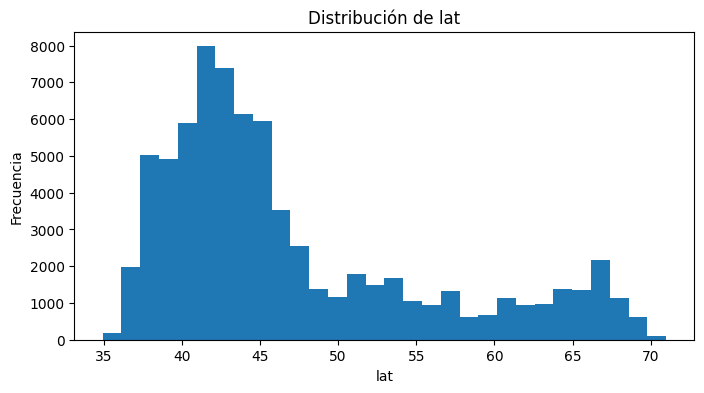

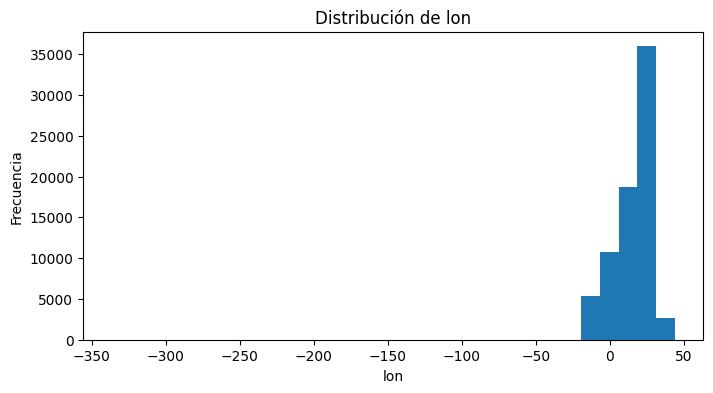

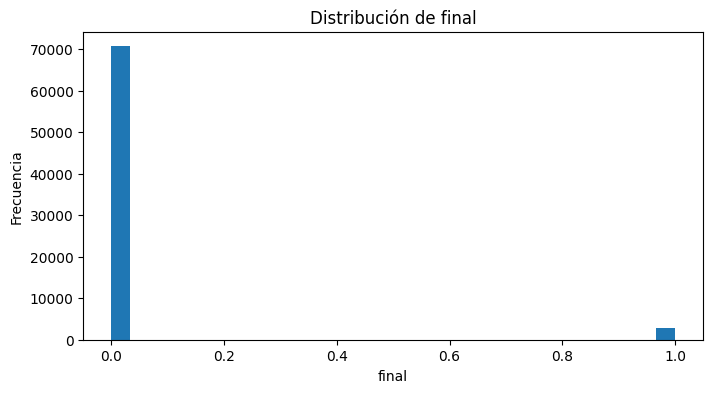

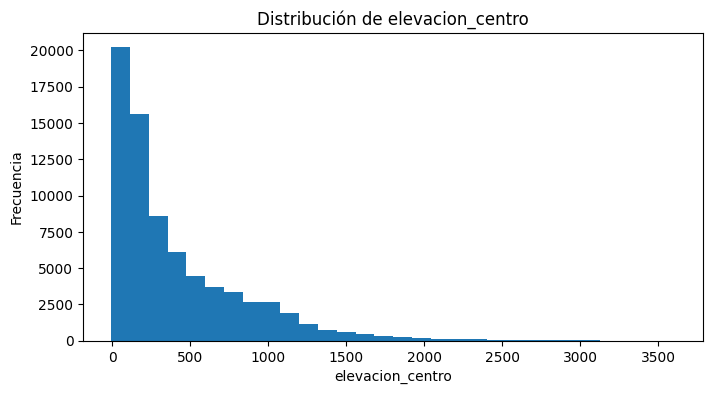

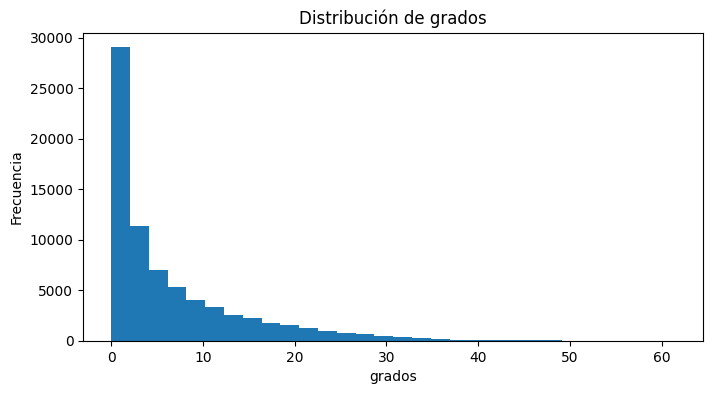

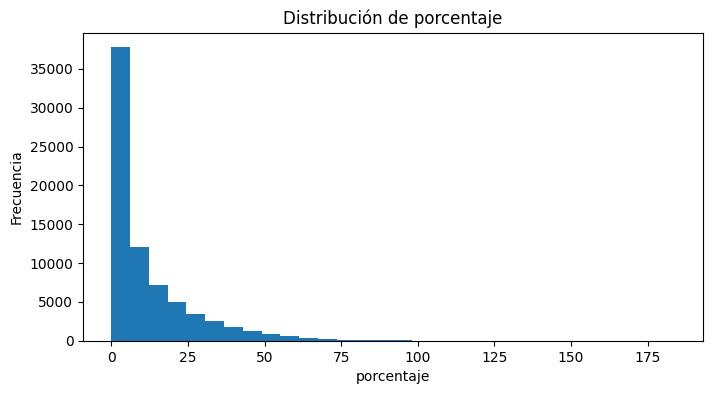

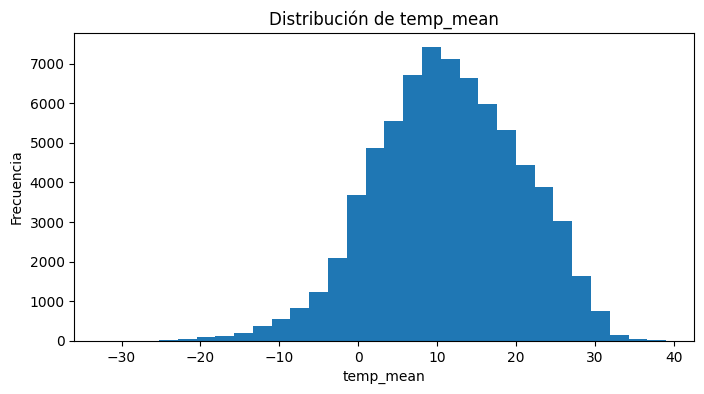

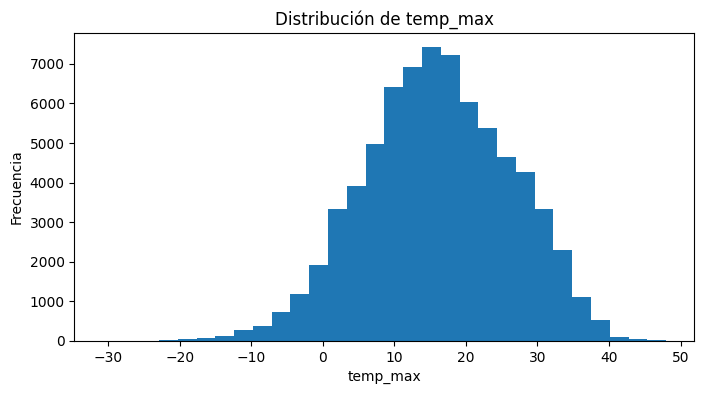

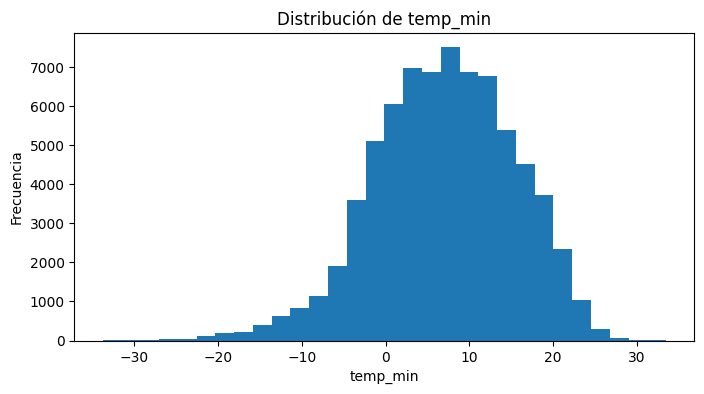

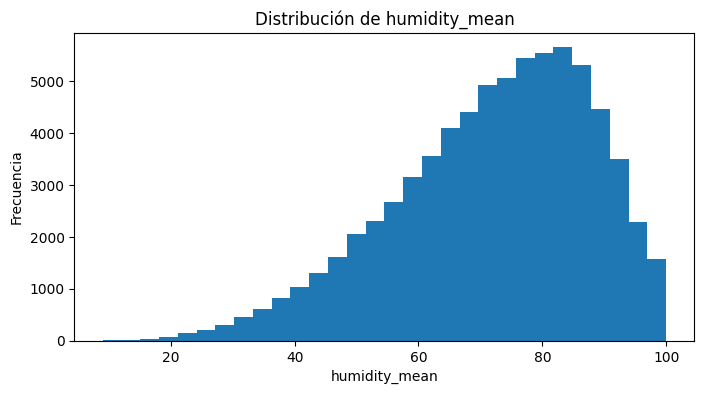

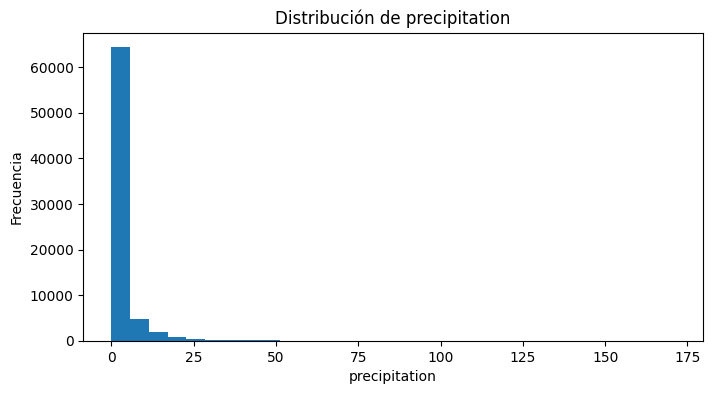

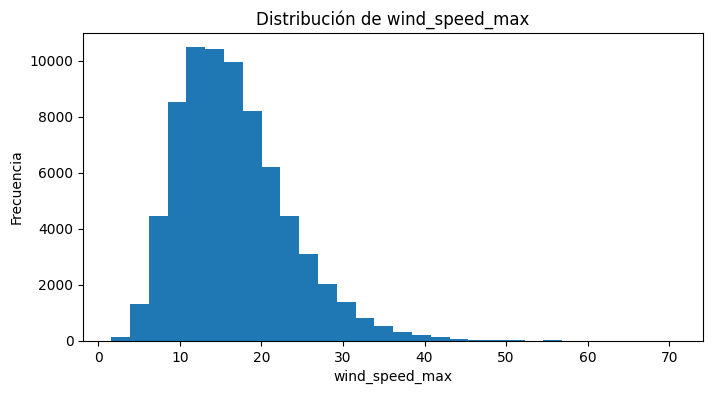

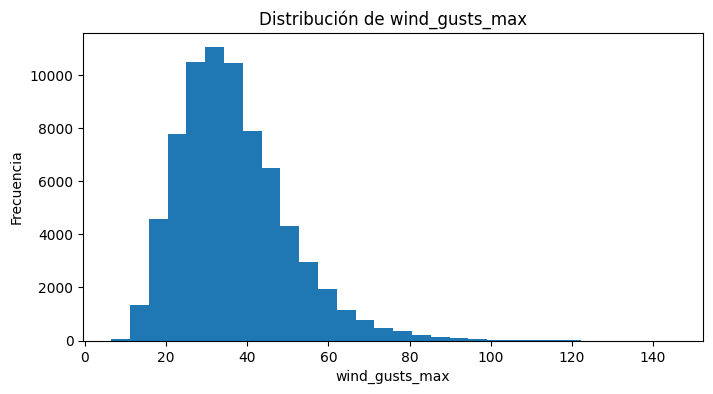

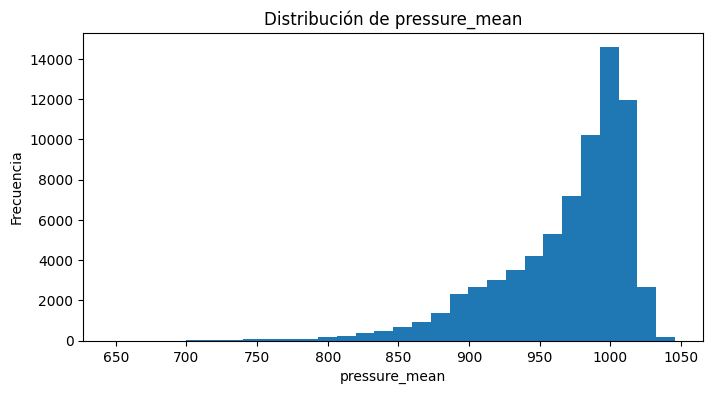

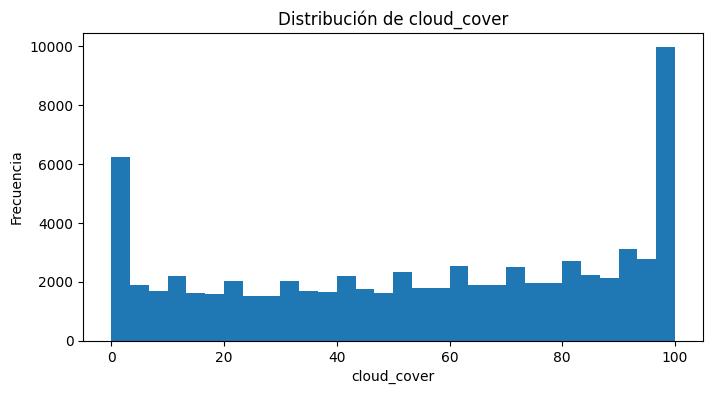

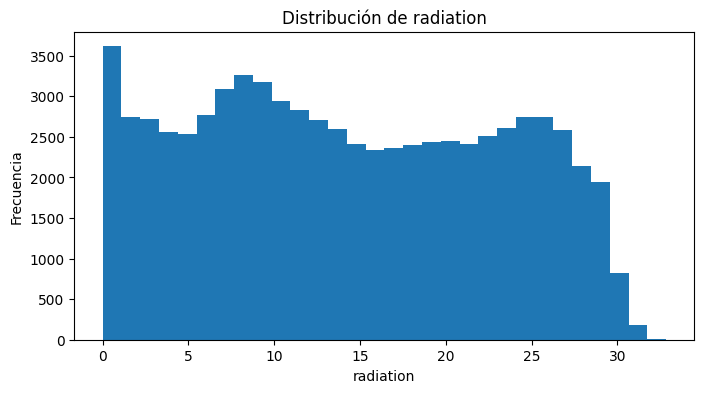

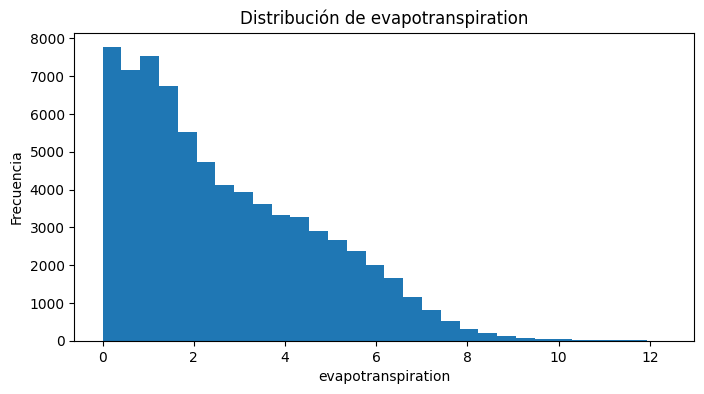

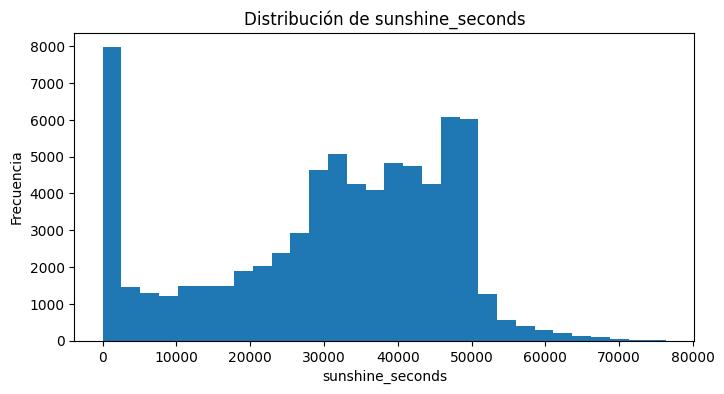

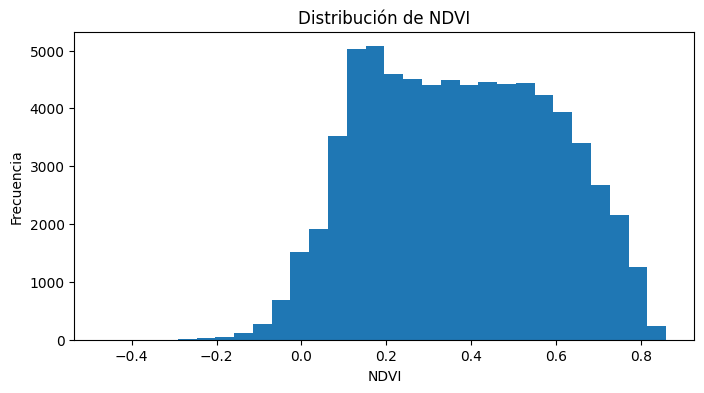

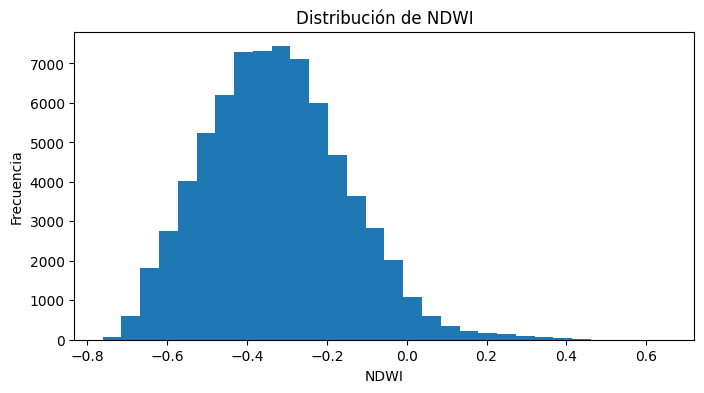

In [38]:
print('Distribucion de las variables numericas:')
for col in df_final.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 4))
    df_final[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

In [39]:
df_final.corr().style.background_gradient(cmap='coolwarm')

,lat,lon,date,final,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
lat,1.000000,0.133672,-0.013959,-0.071645,-0.257423,-0.226953,-0.214967,-0.421397,-0.451469,-0.406835,0.321881,0.007847,0.044888,-0.019231,0.205930,0.310403,-0.332327,-0.350916,-0.252827,-0.078138,0.178169
lon,0.133672,1.000000,0.054382,0.023754,-0.157621,-0.202332,-0.196988,-0.073048,-0.066404,-0.088277,-0.069469,-0.082018,-0.034660,-0.099008,0.143173,-0.062706,-0.021352,-0.008151,-0.002739,-0.159345,0.141300
date,-0.013959,0.054382,1.000000,0.003271,0.040691,0.026281,0.025663,0.044610,0.046442,0.049887,0.042338,0.022907,-0.062758,-0.060406,-0.048598,-0.025971,-0.014966,-0.000802,-0.012912,0.062384,-0.060003
final,-0.071645,0.023754,0.003271,1.000000,-0.029715,-0.000525,-0.000493,0.201165,0.212342,0.180399,-0.270607,-0.070371,0.057578,0.054382,0.038104,-0.190337,0.184904,0.264179,0.157147,-0.046840,0.001382
elevacion_centro,-0.257423,-0.157621,0.040691,-0.029715,1.000000,0.541114,0.533649,-0.114662,-0.083760,-0.142784,-0.091998,0.036159,-0.201881,0.069419,-0.983719,-0.046275,0.101226,0.020198,0.059034,-0.071695,0.049233
grados,-0.226953,-0.202332,0.026281,-0.000525,0.541114,1.000000,0.996224,-0.014818,-0.009689,-0.014371,-0.019819,0.064363,-0.176218,0.098155,-0.533829,-0.026854,0.071787,0.020690,0.043453,0.086963,-0.033947
porcentaje,-0.214967,-0.196988,0.025663,-0.000493,0.533649,0.996224,1.000000,-0.019558,-0.014508,-0.019521,-0.017394,0.064286,-0.175354,0.095640,-0.526265,-0.023506,0.067861,0.017163,0.040528,0.079022,-0.026422
temp_mean,-0.421397,-0.073048,0.044610,0.201165,-0.114662,-0.014818,-0.019558,1.000000,0.985137,0.978185,-0.561178,-0.060180,0.059796,0.062140,0.124253,-0.422982,0.733171,0.848324,0.623569,0.374888,-0.482538
temp_max,-0.451469,-0.066404,0.046442,0.212342,-0.083760,-0.009689,-0.014508,0.985137,1.000000,0.936711,-0.622166,-0.109731,0.011626,0.014758,0.100286,-0.494410,0.776154,0.875274,0.681127,0.351250,-0.467068
temp_min,-0.406835,-0.088277,0.049887,0.180399,-0.142784,-0.014371,-0.019521,0.978185,0.936711,1.000000,-0.455680,0.001321,0.106648,0.106788,0.146839,-0.330013,0.640458,0.769440,0.527938,0.385256,-0.480466


<Axes: >

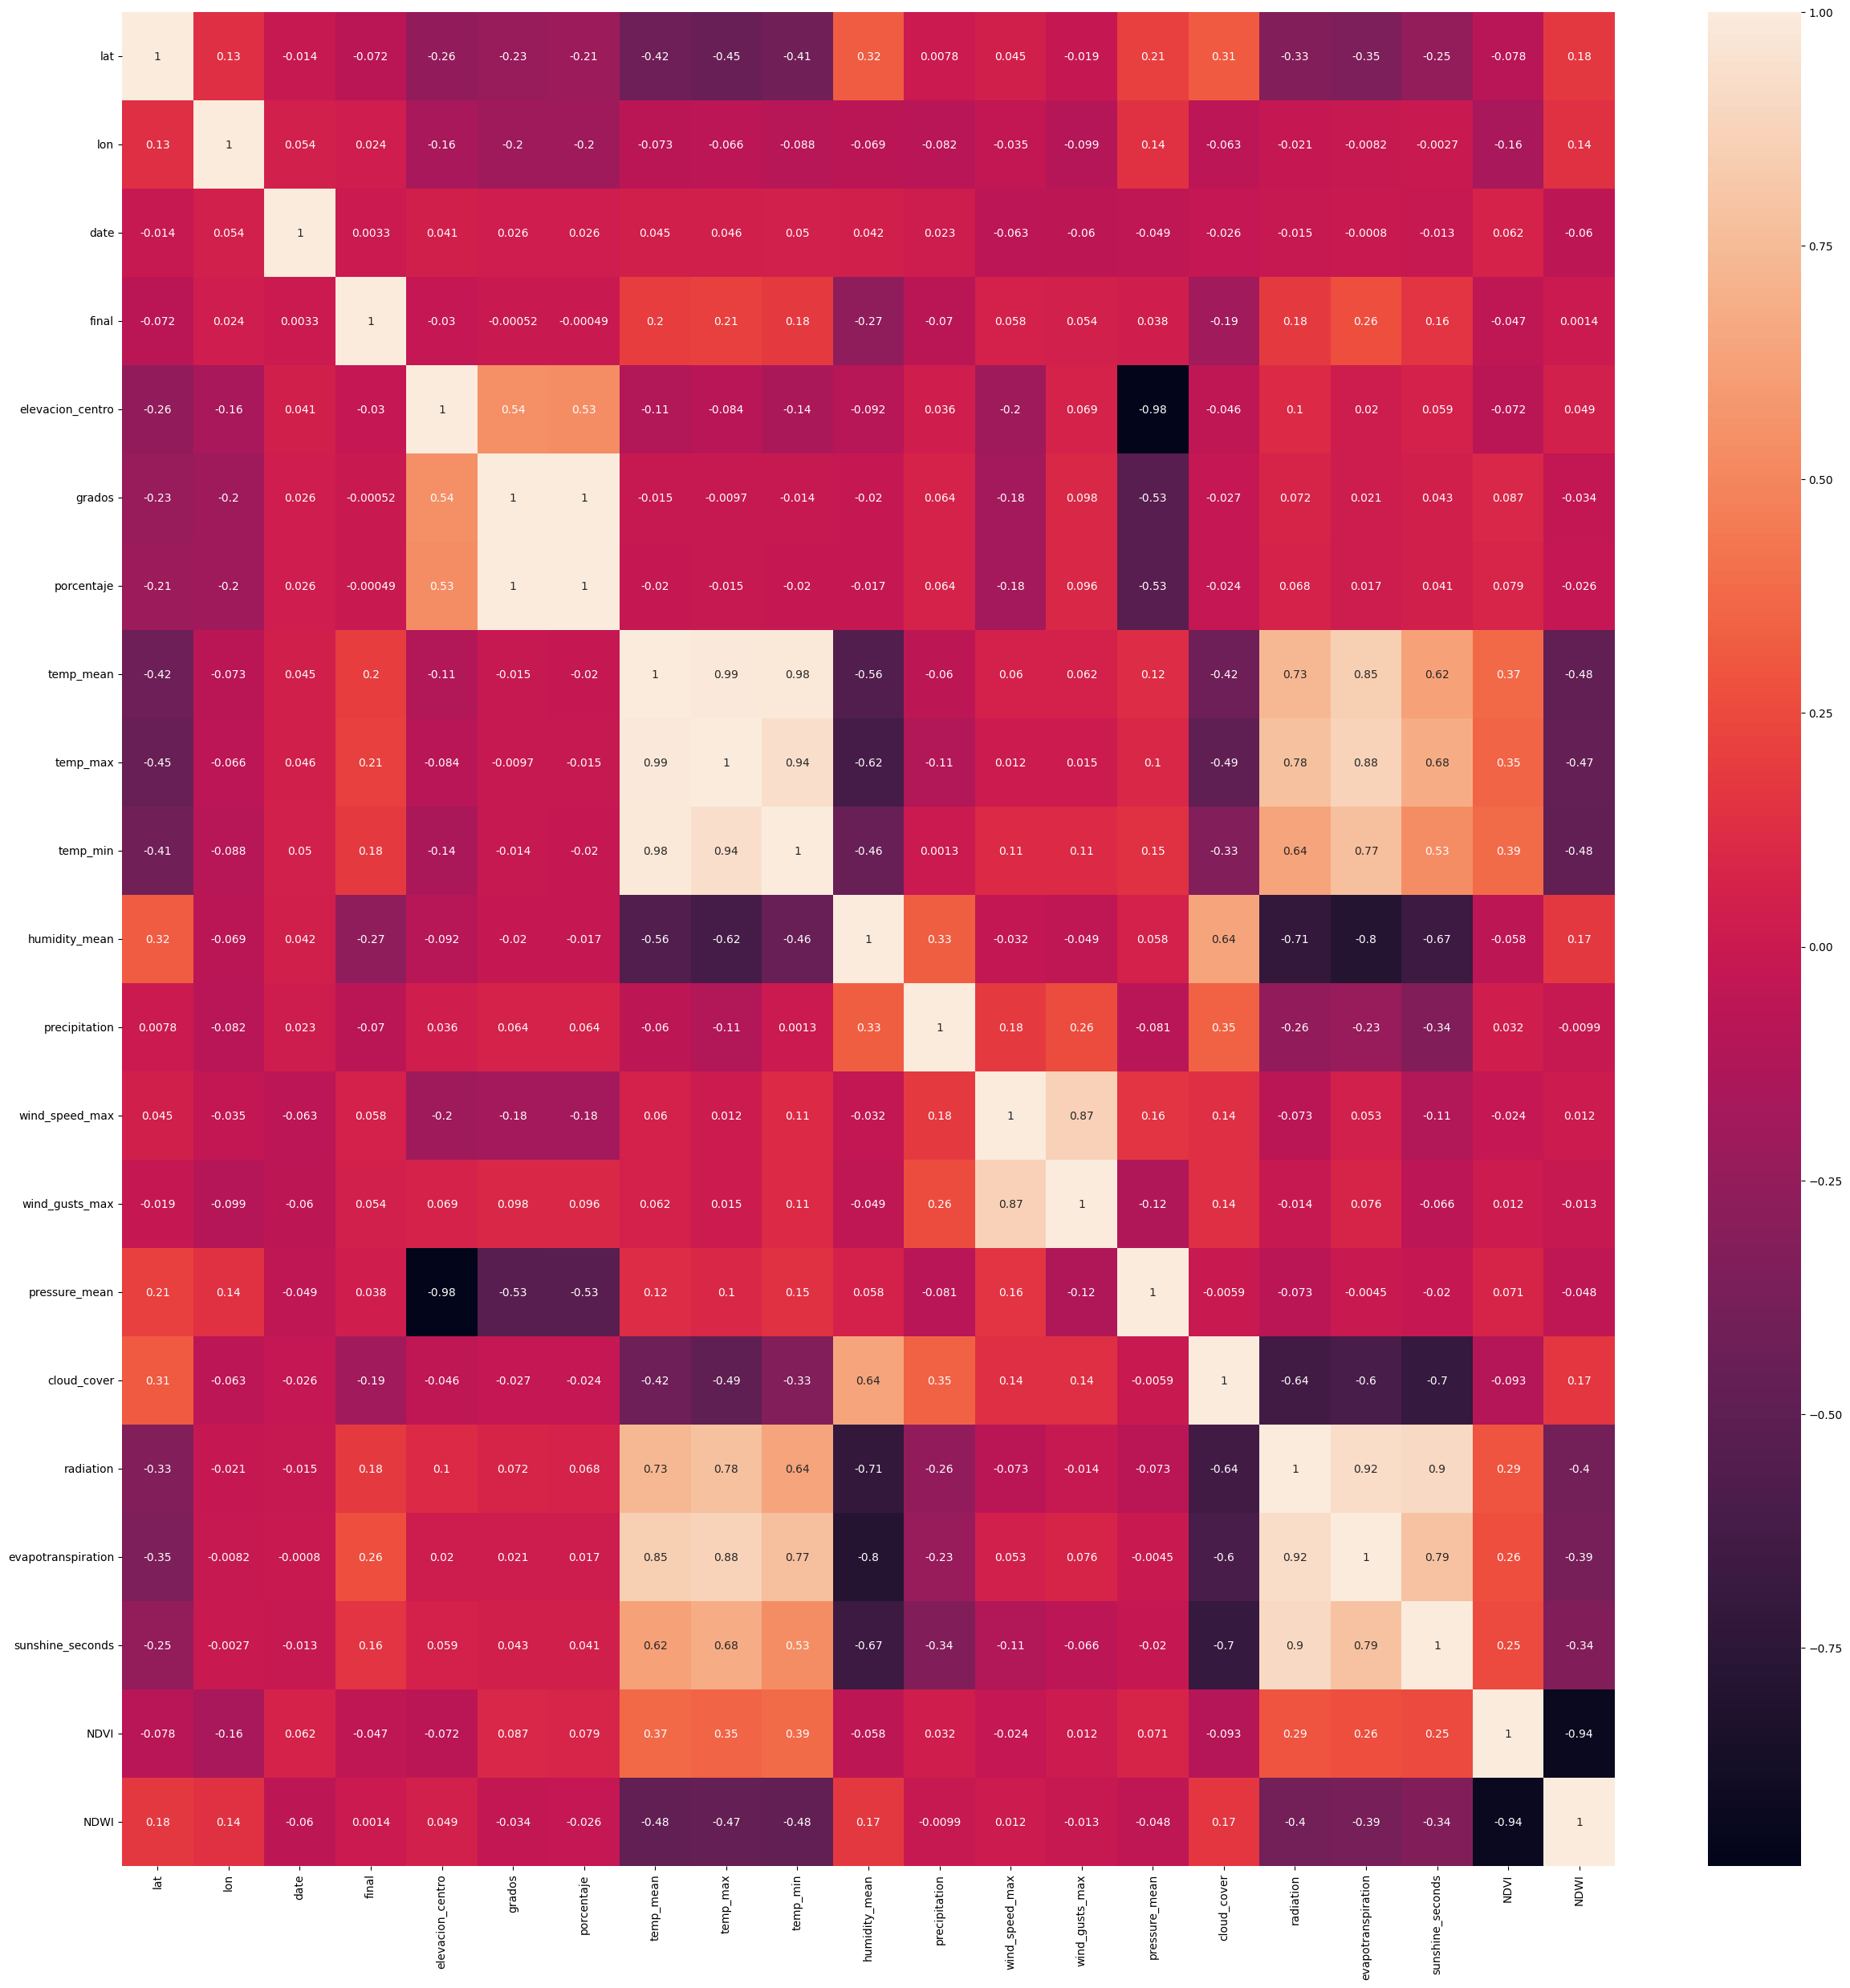

In [40]:
plt.figure(figsize=(30, 30))
sns.heatmap(df_final.corr(), annot=True)

In [ ]:
#Lo mostramos más resumido
matriz_corr = df_final.corr()
listas_corr = matriz_corr.unstack() # Cada variable tendrá una lista con las variables

#2 filtros para mostrar las correlaciones más grandes y para no mostrar por ejemplo: "radiation" - "radiation",
filtro = abs(listas_corr) > 0.5
filtro2 = listas_corr.index.get_level_values(0) != listas_corr.index.get_level_values(1)
listas_corr = listas_corr[filtro & filtro2]

#Eliminamos duplicados de por ejemplo: \"frp_sum\" <=> \"count\" y \"count\" <=> \"frp_sum\"\n",
listas_corr = listas_corr.loc[~listas_corr.index.map(frozenset).duplicated()]
corr_fuertes = listas_corr.reset_index()
corr_fuertes.columns = ['Var1', 'Var2', 'Corr']
corr_fuertes.sort_values(by = "Corr", ascending= False, inplace=True)
corr_fuertes